In [3]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv("Adult.csv")
df

,Unnamed: 0,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,0,39,Govt,77516,College,13,Single,Clerical/Sales,Not-in-family,White,Male,2174,0,40,US,<50K
1,1,50,Self_emp,83311,College,13,Married,White-collar,Husband,White,Male,0,0,13,US,<50K
2,2,38,Private,215646,High-school,9,Separated,Blue-collar,Not-in-family,White,Male,0,0,40,US,<50K
3,3,53,Private,234721,High-school,7,Married,Blue-collar,Husband,Black,Male,0,0,40,US,<50K
4,4,28,Private,338409,College,13,Married,White-collar,Wife,Black,Female,0,0,40,Non-US,<50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,48837,39,Private,215419,College,13,Separated,White-collar,Not-in-family,White,Female,0,0,36,US,<50K
48838,48838,64,NaN,321403,High-school,9,Separated,NaN,Other-relative,Black,Male,0,0,40,US,<50K
48839,48839,38,Private,374983,College,13,Married,White-collar,Husband,White,Male,0,0,50,US,<50K
48840,48840,44,Private,83891,College,13,Separated,Clerical/Sales,Own-child,Asian-Pac-Islander,Male,5455,0,40,US,<50K


In [5]:
df.drop("Unnamed: 0",axis=1,inplace=True)

In [6]:
df.isnull().sum()

age                  0
workclass         2799
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country       0
income               0
dtype: int64

In [7]:
df['workclass'].fillna(df['workclass'].mode()[0],inplace=True)
df['occupation'].fillna(df['occupation'].mode()[0],inplace=True)

In [8]:
(df.isnull().sum()/df.shape[0]*100)

age               0.0
workclass         0.0
fnlwgt            0.0
education         0.0
education_num     0.0
marital_status    0.0
occupation        0.0
relationship      0.0
race              0.0
sex               0.0
capital_gain      0.0
capital_loss      0.0
hours_per_week    0.0
native_country    0.0
income            0.0
dtype: float64

In [9]:
df.dropna(axis=0,inplace= True)

In [10]:
df['occupation'].value_counts()

occupation
Blue-collar       17368
White-collar      13704
Clerical/Sales    11115
Service/Manual     6655
Name: count, dtype: int64

In [11]:
from sklearn.preprocessing import StandardScaler
st_scalar = StandardScaler()
num_col = df.select_dtypes(include='number').columns
print(num_col)
for i in num_col:
    df[i]= st_scalar.fit_transform(df[[i]])

Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')


In [12]:
from sklearn.preprocessing import LabelEncoder
lab_enc = LabelEncoder()
cat_col = df.select_dtypes(include='object').columns
for i in cat_col:
    df[i]= lab_enc.fit_transform(df[[i]])

In [13]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,0.025996,0,-1.061979,0,1.136512,2,1,1,4,1,0.146932,-0.217127,-0.034087,1,0
1,0.828308,2,-1.007104,0,1.136512,0,3,0,4,1,-0.144804,-0.217127,-2.213032,1,0
2,-0.046942,1,0.246034,1,-0.419335,1,0,1,4,1,-0.144804,-0.217127,-0.034087,1,0
3,1.047121,1,0.426663,1,-1.197259,0,0,0,2,1,-0.144804,-0.217127,-0.034087,1,0
4,-0.776316,1,1.408530,0,1.136512,0,3,5,2,0,-0.144804,-0.217127,-0.034087,0,0


In [14]:
x = df.drop('income',axis=1)
y = df['income']

In [15]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3)

In [16]:
input_dim = x.shape[1]

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten

In [18]:
model  = Sequential()
model.add(Dense(32,activation='relu',input_shape=(input_dim,)))
model.add(Dense(64,activation='relu'))
model.add(Flatten())
model.add(Dense(1,activation='sigmoid'))

In [19]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [20]:
history = model.fit(x_train,y_train,
            validation_data = (x_test,y_test),
            epochs = 50)

Epoch 1/50
1069/1069 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8370 - loss: 0.3506 - val_accuracy: 0.8453 - val_loss: 0.3307
Epoch 2/50
1069/1069 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8488 - loss: 0.3248 - val_accuracy: 0.8438 - val_loss: 0.3330
Epoch 3/50
1069/1069 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8501 - loss: 0.3201 - val_accuracy: 0.8450 - val_loss: 0.3287
Epoch 4/50
1069/1069 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8517 - loss: 0.3176 - val_accuracy: 0.8491 - val_loss: 0.3216
Epoch 5/50
1069/1069 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8518 - loss: 0.3157 - val_accuracy: 0.8484 - val_loss: 0.3218
Epoch 6/50
1069/1069 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8521 - loss: 0.3141 - val_accuracy: 0.8497 - val_loss: 0.3205
Epoch 7/50
1069/1069 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8526 - loss: 0.3129 - val_accuracy: 0.8479 - val_loss: 0.3224
Epoch 8/50
1069/1069 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8539 - loss: 0.3118 - 

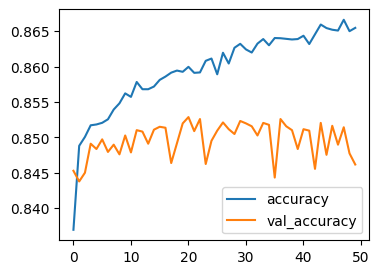

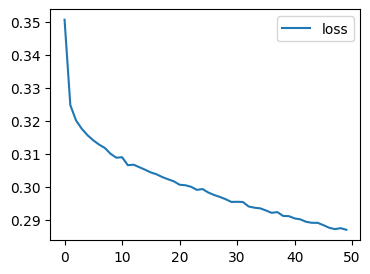

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(4,3))
sns.lineplot(history.history['accuracy'],label ='accuracy')
sns.lineplot(history.history['val_accuracy'],label ='val_accuracy')
plt.legend()
plt.show()

import matplotlib.pyplot as plt
plt.figure(figsize=(4,3))
plt.plot(history.history['loss'],label = 'loss')
plt.legend()
plt.show()

In [22]:
model.save("ANN_model.keras")